# home_energy_lab — does GP + soft-EM regime-awareness earn its keep for home solar/battery/HVAC dispatch?

The fifth application of this codebase's GP-soft-EM-decision stack, and the first built on
**genuinely open, personal-scale data** rather than gov/corporate-collected records: real 10-year
Vancouver, BC weather (Open-Meteo, live-verified), a load model calibrated exactly to Fraser's own
real BC Hydro bill, and real BC Hydro rate/rebate structures (verified directly from bchydro.com).

**Four phases, four real findings, none assumed going in:**
1. **Phase 0** — the winter low-solar/high-heating "stress regime" is real (1.78x co-occurrence
   excess, 4.5x day-to-day persistence), confirmed directly on real data.
2. **Phase 1** — the top of the dispatch ladder is a **statistical tie**: all eight proactive
   methods within $36/yr, the top three within $5 (~1% of the bill). The two effects large enough to
   be real are proactive off-peak pre-charging (~$130-165/yr) and a peak-window battery reserve
   (~$25/yr) — neither a forecasting result. Regime-awareness, tested on a lever verified capable of moving the number,
   is a **null**.
3. **Phase 2** — GPC's calibrated mean beats an SVM control, but posterior variance (the sequential
   value-of-information mechanism) adds nothing on top, across the entire cost-ratio range tested.
4. **Phase 3** — the cost-minimizing system is a modest **4-6kW of solar and no battery at all**,
   less than half the cost of the 8kW/13.5kWh reference system used as this lab's own illustrative
   default throughout — and a battery with no solar shows *negative* self-sufficiency even while
   *reducing* the bill. The no-battery result holds at every capacity-fade level tested.

> **This notebook was rebuilt 2026-08-05 after an internal code review (`CODE_REVIEW.md`) found two
> structural modeling errors, one unexamined economic assumption, an undischarged sourcing deferral,
> and a policy class the lab's own research had asked for but never tested.** Phases 1 and 3 were
> re-run and their headlines changed; Phase 0 and Phase 2 were re-verified and stand unaltered.
>
> **One of the review's own corrections was then partly overturned by another.** Fixing the export
> credit reversed the finding that a model-free calendar rule beat the fitted GP — the GP ends up
> ~$5/yr ahead, not $1 behind — and shrank the regime layer's penalty from $22/yr to $4/yr. Both
> revisions are recorded in place rather than folded away, because the sequence is the point: a fix
> to the *economics* changed the verdict on the *models*.

> **Disclaimer** (carried through every phase of this lab): illustrative and educational, anchored
> to real data and real rate/rebate structures, but not a substitute for a real home-energy audit,
> a licensed electrician/installer's quote, or professional financial advice.

**Read alongside:** `LAB_PLAN.md`, `RESULTS_PHASE0-3.md`, `CODE_REVIEW.md`, `research/` (eight
sourced domain passes),
and `SCENARIO_BUILDER.ipynb` (a companion notebook letting you plug in your own hardware prices,
rebate rules, and electricity rates as they change).

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e5e4e0", "#fcfcfb"
C0, C1, C2, C3, C4 = "#9a9890", "#c9622a", "#e0a83a", "#1baf7a", "#2a78d6"
POS, NEG = C4, C1

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "figure.dpi": 110,
})

phase0 = json.load(open("results_phase0.json"))
phase1 = json.load(open("results_phase1.json"))
boot2 = json.load(open("results/bootstrap_dispatch_voi.json"))
sweep2 = json.load(open("results/cost_ratio_sweep_dispatch.json"))
phase3 = json.load(open("results_phase3.json"))
print("loaded results_phase0/1/3.json + results/bootstrap_dispatch_voi.json + "
      "results/cost_ratio_sweep_dispatch.json")

loaded results_phase0/1/3.json + results/bootstrap_dispatch_voi.json + results/cost_ratio_sweep_dispatch.json


## Phase 0 — real data, real models, a real stress-regime check

10 real years of Vancouver weather (2016-2025), a load model calibrated exactly to Fraser's own
real BC Hydro bill. The central question: does a real, correlated "winter low-solar + high-heating"
stress regime actually exist in the data, or is it an assumption?

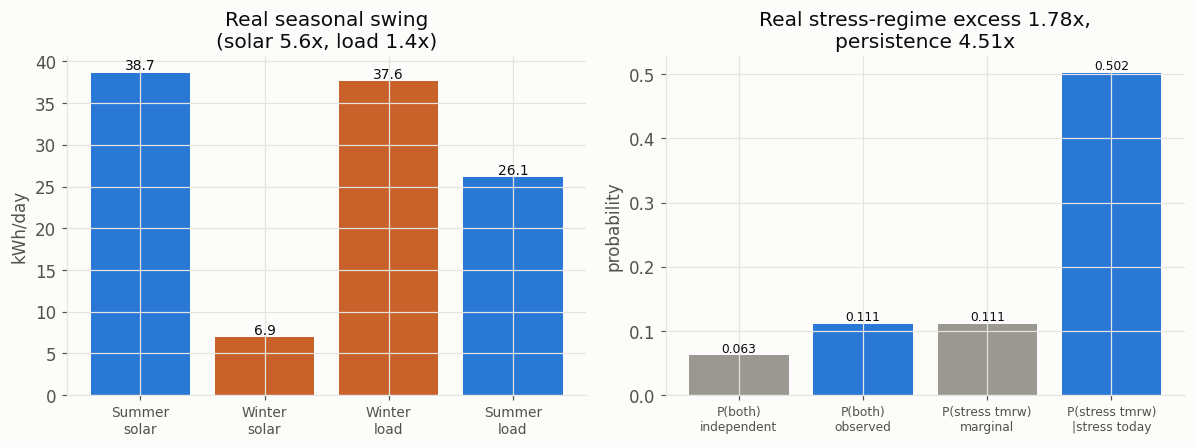

Real: low-solar/high-heat co-occurs 1.78x more than independence predicts; a stress day is 4.51x more likely to be followed by another stress day than the marginal rate.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

seas = phase0["seasonal_shape"]
ax = axes[0]
labels = ["Summer\nsolar", "Winter\nsolar", "Winter\nload", "Summer\nload"]
vals = [seas["summer_solar_kwh_day"], seas["winter_solar_kwh_day"],
        seas["winter_load_kwh_day"], seas["summer_load_kwh_day"]]
colors = [C4, C1, C1, C4]
ax.bar(range(4), vals, color=colors)
ax.set_xticks(range(4)); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("kWh/day")
ax.set_title("Real seasonal swing\n(solar 5.6x, load 1.4x)")
for x, v in zip(range(4), vals):
    ax.text(x, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)

ax = axes[1]
sr = phase0["stress_regime_check"]
pc = phase0["persistence_check"]
labels2 = ["P(both)\nindependent", "P(both)\nobserved", "P(stress tmrw)\nmarginal", "P(stress tmrw)\n|stress today"]
vals2 = [sr["p_both_if_independent"], sr["p_both_observed"],
         pc["p_stress_marginal"], pc["p_stress_tomorrow_given_stress_today"]]
colors2 = [C0, C4, C0, C4]
ax.bar(range(4), vals2, color=colors2)
ax.set_xticks(range(4)); ax.set_xticklabels(labels2, fontsize=8)
ax.set_ylabel("probability")
ax.set_title(f"Real stress-regime excess {sr['excess_ratio_vs_independence']:.2f}x,\n"
             f"persistence {pc['persistence_ratio']:.2f}x")
for x, v in zip(range(4), vals2):
    ax.text(x, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout(); plt.show()
print(f"Real: low-solar/high-heat co-occurs {sr['excess_ratio_vs_independence']:.2f}x more than "
      f"independence predicts; a stress day is {pc['persistence_ratio']:.2f}x more likely to be "
      f"followed by another stress day than the marginal rate.")

## Phase 1 — the dispatch ladder, with model-free ablations

Fit on one real training year (2016), scored on the real held-out 2017-2025 record.

**Re-run 2026-08-05.** The original four-method ladder reported "Method 2 (plain GP forecast) wins."
The code review found that conclusion unsupported in two independent ways, and both fixes are now
in the ladder:

- **The ladder had no model-free control.** Two ablations were added — **0b** (yesterday's realized
  net load, no model) and **1b** (a calendar rule using *no data at all*) — plus **3c** (calendar +
  reserve), a fully model-free reference.
- **Method 3's regime margin was structurally dead.** It was added to a charge target already
  clipped at battery capacity, and real daily net load exceeds capacity on 49.5% of days — so on
  exactly the high-demand days the layer exists for, the margin was mathematically zero. Measured,
  it fired *only* on days averaging 3.9 kWh of net load and never on days averaging 25.7 kWh: an
  inverted stress response. It now sizes a **peak-window discharge reserve** instead (hold SOC back
  through standard-rate hours so it survives for the 4-9pm surcharge), which is not bounded by the
  charge target. **3b** applies the same reserve at constant size, isolating the soft-EM layer.
- **Method 4** (added for H3) is tier-threshold-aware: suppress off-peak pre-charging once the
  month's running total passes BC Hydro's real 675 kWh Step 1 threshold. This is the policy class
  `research/04` explicitly asked for and no method had addressed.

**Read the bar heights, not the ordering.** All eight proactive methods span $36/yr and the top three $5
— about 1% of the bill, which is inside this model's own resolution. What the chart actually shows
is one large step (any proactive off-peak pre-charging, $130-165/yr off Method 0) and one modest one
(adding a peak-window reserve, ~$25/yr). Neither is a forecasting effect.

Bars in grey consume no fitted model; blue is the GP; green is the GP + soft-EM layer.

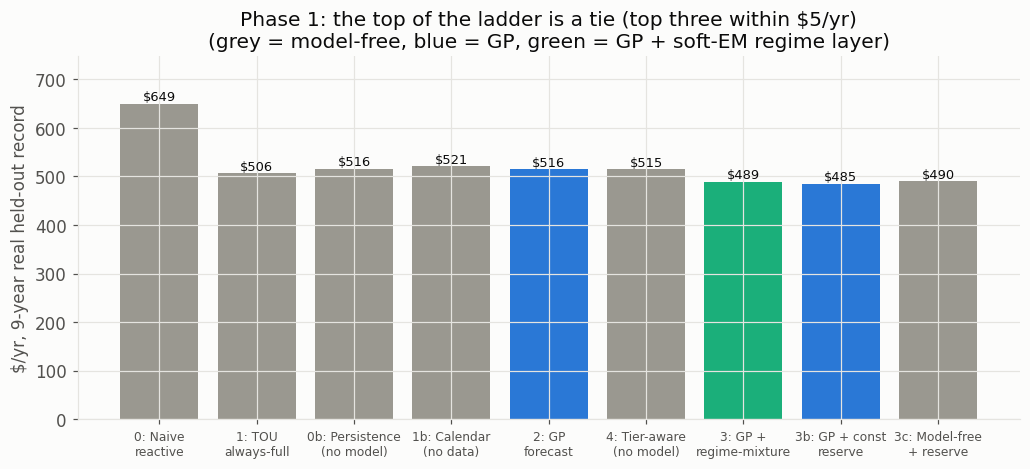

Cheapest: 3b_gp_constant_reserve at $485/yr
Calendar rule (zero data) $521/yr vs fitted GP $516/yr -> the GP buys $+5/yr (+1.1% of the bill)
Regime-sized reserve $489/yr vs constant reserve $485/yr -> the soft-EM layer costs $+4/yr

Spread across every proactive method: $36/yr on a ~$485/yr bill (7.4%) -- a tie, not a ranking.
Each method's rate election (TOD opt-in vs tiered-only), added for H3:
  0_naive_reactive         TOD $  649  tiered-only $  669  -> tod_optin
  1_tou_always_full        TOD $  506  tiered-only $  702  -> tod_optin
  0b_persistence_no_model  TOD $  516  tiered-only $  699  -> tod_optin
  1b_calendar_only         TOD $  521  tiered-only $  697  -> tod_optin
  2_gp_forecast            TOD $  516  tiered-only $  699  -> tod_optin
  4_tier_threshold_aware   TOD $  515  tiered-only $  692  -> tod_optin
  3_gp_regime_mixture      TOD $  489  tiered-only $  703  -> tod_optin
  3b_gp_constant_reserve   TOD $  485  tiered-only $  699  -> tod_optin
  3c_model_free_referenc

In [3]:
names = ["0_naive_reactive", "1_tou_always_full", "0b_persistence_no_model",
         "1b_calendar_only", "2_gp_forecast", "4_tier_threshold_aware",
         "3_gp_regime_mixture", "3b_gp_constant_reserve", "3c_model_free_reference"]
labels = ["0: Naive\nreactive", "1: TOU\nalways-full", "0b: Persistence\n(no model)",
          "1b: Calendar\n(no data)", "2: GP\nforecast", "4: Tier-aware\n(no model)",
          "3: GP +\nregime-mixture", "3b: GP + const\nreserve", "3c: Model-free\n+ reserve"]
vals = [phase1[n]["total_cost_usd_per_year"] for n in names]
# grey = consumes no fitted model, blue = GP, green = GP + soft-EM
colors = [C0, C0, C0, C0, C4, C0, C3, C4, C0]

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.bar(range(len(names)), vals, color=colors)
ax.set_xticks(range(len(names))); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("$/yr, 9-year real held-out record")
ax.set_ylim(0, max(vals) * 1.15)
ax.set_title("Phase 1: the top of the ladder is a tie (top three within $5/yr)\n"
             "(grey = model-free, blue = GP, green = GP + soft-EM regime layer)")
for x, v in zip(range(len(names)), vals):
    ax.text(x, v, f"${v:.0f}", ha="center", va="bottom", fontsize=8.5)
plt.tight_layout(); plt.show()

best = min(names, key=lambda n: phase1[n]["total_cost_usd_per_year"])
best_val = phase1[best]["total_cost_usd_per_year"]
gp_val = phase1["2_gp_forecast"]["total_cost_usd_per_year"]
cal_val = phase1["1b_calendar_only"]["total_cost_usd_per_year"]
reg_val = phase1["3_gp_regime_mixture"]["total_cost_usd_per_year"]
const_val = phase1["3b_gp_constant_reserve"]["total_cost_usd_per_year"]
print(f"Cheapest: {best} at ${best_val:.0f}/yr")
print(f"Calendar rule (zero data) ${cal_val:.0f}/yr vs fitted GP ${gp_val:.0f}/yr "
      f"-> the GP buys ${cal_val - gp_val:+.0f}/yr ({(cal_val-gp_val)/cal_val:+.1%} of the bill)")
print(f"Regime-sized reserve ${reg_val:.0f}/yr vs constant reserve ${const_val:.0f}/yr "
      f"-> the soft-EM layer costs ${reg_val - const_val:+.0f}/yr")
spread = max(vals[1:]) - min(vals[1:])
print(f"\nSpread across every proactive method: ${spread:.0f}/yr on a ~${min(vals):.0f}/yr bill "
      f"({spread/min(vals):.1%}) -- a tie, not a ranking.")
print("Each method's rate election (TOD opt-in vs tiered-only), added for H3:")
for n in names:
    r = phase1[n]
    print(f"  {n:24s} TOD ${r['cost_tod_optin_usd_per_year']:5.0f}  "
          f"tiered-only ${r['cost_tiered_only_usd_per_year']:5.0f}  -> {r['rate_election']}")
for n in names:
    print(f"  {n:22s}  ${phase1[n]['total_cost_usd_per_year']:6.0f}/yr  "
          f"self-sufficiency={phase1[n]['self_sufficiency']:.1%}")

## Phase 2 — the sequential value-of-information dispatch layer

A real, data-derived "high-demand day" classifier (checked for separability first: val AP≈0.80,
neither too easy nor too hard). GPC's calibrated mean beats SVM robustly — but posterior variance
(the actual VoI mechanism) adds nothing on top, across the *entire* cost-ratio range tested.

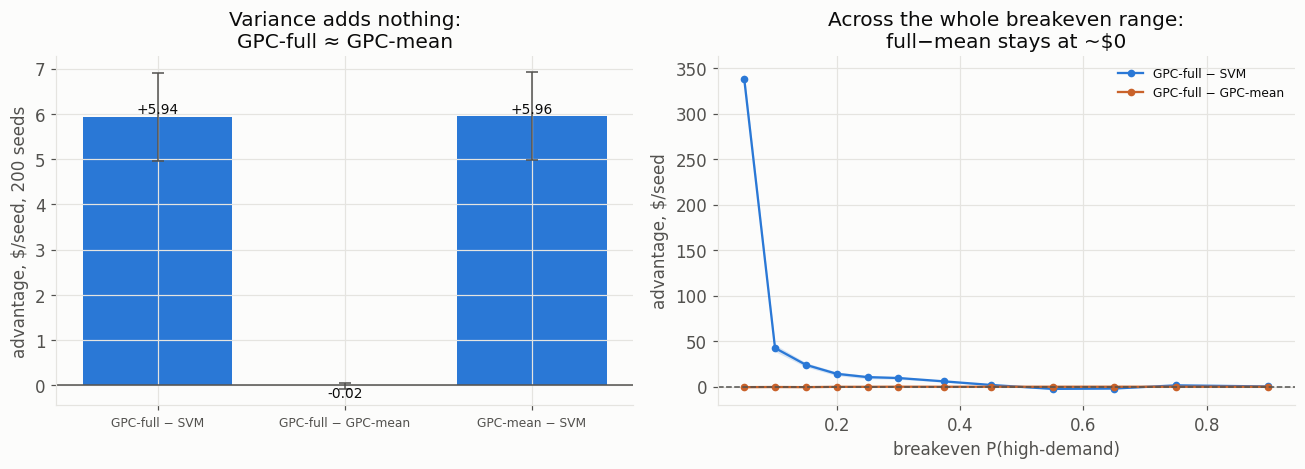

In [4]:
conds = ("svm", "gpc_mean", "gpc_full")
cond_labels = {"svm": "SVM", "gpc_mean": "GPC (mean only)", "gpc_full": "GPC (full posterior)"}
cond_colors = {"svm": C1, "gpc_mean": C3, "gpc_full": C4}


def paired_bootstrap_ci(diffs, n_boot=10000, seed=0):
    rng = np.random.default_rng(seed)
    diffs = np.asarray(diffs)
    n = len(diffs)
    boots = np.array([diffs[rng.integers(0, n, n)].mean() for _ in range(n_boot)])
    return float(diffs.mean()), float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))


fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

vals2 = {c: np.array([r[c]["realized_total_usd"] for r in boot2["runs"]]) for c in conds}
deltas = [("GPC-full \u2212 SVM", vals2["gpc_full"] - vals2["svm"]),
          ("GPC-full \u2212 GPC-mean", vals2["gpc_full"] - vals2["gpc_mean"]),
          ("GPC-mean \u2212 SVM", vals2["gpc_mean"] - vals2["svm"])]
cis = [paired_bootstrap_ci(d) for _, d in deltas]
means = [ci[0] for ci in cis]
colors = [POS if m >= 0 else NEG for m in means]
err = np.array([[m - lo, hi - m] for m, (_, lo, hi) in zip(means, cis)]).T
ax = axes[0]
ax.bar(range(3), means, yerr=err, color=colors, capsize=4, error_kw=dict(ecolor=INK2, elinewidth=1))
ax.axhline(0, color=INK2, linewidth=1)
ax.set_xticks(range(3)); ax.set_xticklabels([d[0] for d in deltas], fontsize=8)
ax.set_ylabel("advantage, $/seed, 200 seeds")
ax.set_title("Variance adds nothing:\nGPC-full \u2248 GPC-mean")
for x, m in zip(range(3), means):
    ax.text(x, m, f"{m:+.2f}", ha="center", va="bottom" if m >= 0 else "top", fontsize=9)

ax = axes[1]
grid = sweep2["breakeven_p_grid"]
runs = sweep2["runs"]
d_svm, d_mean = [], []
for gi in range(len(grid)):
    full = np.array([r["sweep"][gi]["gpc_full"]["realized_total"] for r in runs])
    svm = np.array([r["sweep"][gi]["svm"]["realized_total"] for r in runs])
    mean_ = np.array([r["sweep"][gi]["gpc_mean"]["realized_total"] for r in runs])
    d_svm.append(paired_bootstrap_ci(full - svm))
    d_mean.append(paired_bootstrap_ci(full - mean_))
for deltas_, label, color in [(d_svm, "GPC-full \u2212 SVM", C4), (d_mean, "GPC-full \u2212 GPC-mean", C1)]:
    pts = np.array(deltas_)
    ax.plot(grid, pts[:, 0], "-o", color=color, label=label, markersize=4)
    ax.fill_between(grid, pts[:, 1], pts[:, 2], color=color, alpha=0.18, linewidth=0)
ax.axhline(0, color=INK2, linewidth=1, linestyle="--")
ax.set_xlabel("breakeven P(high-demand)")
ax.set_ylabel("advantage, $/seed")
ax.set_title("Across the whole breakeven range:\nfull\u2212mean stays at ~$0")
ax.legend(frameon=False, fontsize=8)

plt.tight_layout(); plt.show()

## Phase 3 — the capacity-sizing solver: how much do you actually need?

This phase has now survived **two** real economic corrections, both caught before they could stand
as findings:

1. **(2026-08-04)** The earlier-sourced hardware economics were US market data including the US
   federal tax credit, which doesn't apply to a real BC household — corrected with real BC Hydro
   rebates and real CAD costs.
2. **(2026-08-05, re-run)** **Grid export was valued at $0 across the entire lab** — simulated in
   three modules, monetized in none. The 8kW reference system exports over 4,000 kWh/yr. Now
   credited under BC Hydro's real Self-Generation Service Rate.

**The export lookup is this lab's strongest argument for verify-don't-recall: BC Hydro replaced the
program on 2026-07-01, five weeks before the check.** Legacy net metering (RS 1289, annual kWh
banking) closed to new customers, replaced by RS 2289 — a flat 10¢/kWh monetary credit settled *per
billing cycle* and capped at that month's energy charge. Any figure recalled rather than fetched
would have described the closed program.

The cost-minimizing system is still much smaller than the 8kW/13.5kWh default used in Phases 1-2 —
but crediting export narrowed the 4kW-vs-6kW margin from $107/yr to $7/yr, so the honest answer is
now **"4-6kW, no battery"** rather than a confident "4kW".

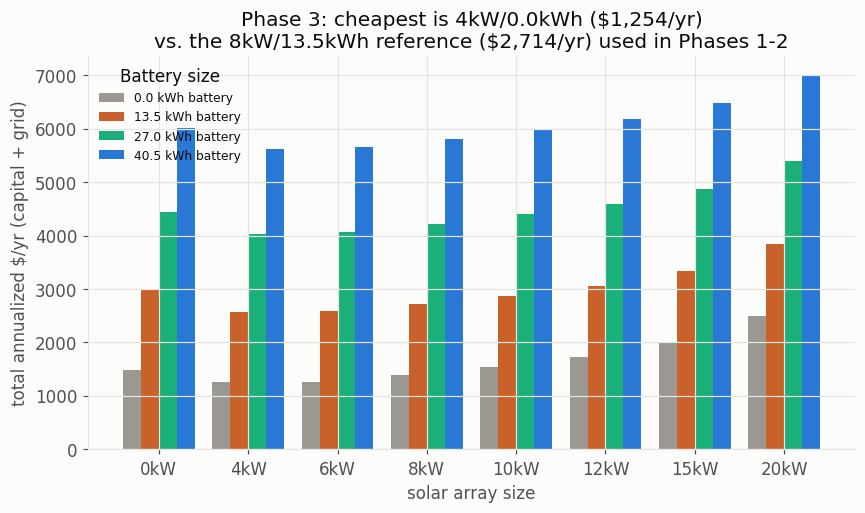

Cost-minimizing: 4.0kW solar + 0.0kWh battery, $1,254/yr, self-sufficiency 25.4%
Reference (8kW/13.5kWh): $2,714/yr, self-sufficiency 42.2%
Savings from choosing the cost-optimal system: $1,460/yr (54% cheaper)

Runner-up: 6kW/0.0kWh at $1,261/yr -- only $7/yr more.
That margin is inside this model's own resolution, so the honest answer is a RANGE (4-6kW, no battery), not a single point.

Export rises fast with array size, and RS 2289 settles monthly -- surplus in a low-bill summer month is forfeited, not banked into winter:
    0.0kW solar, no battery: export       0 kWh/yr   total $1,489/yr
    4.0kW solar, no battery: export   1,051 kWh/yr   total $1,254/yr
    6.0kW solar, no battery: export   2,476 kWh/yr   total $1,261/yr
    8.0kW solar, no battery: export   4,108 kWh/yr   total $1,390/yr
   10.0kW solar, no battery: export   5,849 kWh/yr   total $1,546/yr
   12.0kW solar, no battery: export   7,651 kWh/yr   total $1,721/yr
   15.0kW solar, no battery: export  10,429 kWh/yr   to

In [5]:
grid_rows = phase3["grid"]
solar_vals = sorted(set(r["solar_kw"] for r in grid_rows))
battery_vals = sorted(set(r["battery_kwh"] for r in grid_rows))

fig, ax = plt.subplots(figsize=(8, 4.8))
width = 0.8 / len(battery_vals)
battery_colors = [C0, C1, C3, C4]
for bi, bkwh in enumerate(battery_vals):
    ys = [next(r["total_annual_usd"] for r in grid_rows
               if r["solar_kw"] == s and r["battery_kwh"] == bkwh) for s in solar_vals]
    xs = np.arange(len(solar_vals)) + (bi - (len(battery_vals) - 1) / 2) * width
    ax.bar(xs, ys, width=width, color=battery_colors[bi % len(battery_colors)],
           label=f"{bkwh:.1f} kWh battery")

best = phase3["best"]
ref = phase3["reference"]
ax.set_xticks(range(len(solar_vals)))
ax.set_xticklabels([f"{s:.0f}kW" for s in solar_vals])
ax.set_xlabel("solar array size")
ax.set_ylabel("total annualized $/yr (capital + grid)")
ax.set_title(f"Phase 3: cheapest is {best['solar_kw']:.0f}kW/{best['battery_kwh']:.1f}kWh "
             f"(${best['total_annual_usd']:,.0f}/yr)\n"
             f"vs. the {ref['solar_kw']:.0f}kW/{ref['battery_kwh']:.1f}kWh reference "
             f"(${ref['total_annual_usd']:,.0f}/yr) used in Phases 1-2")
ax.legend(frameon=False, fontsize=8, title="Battery size")
plt.tight_layout(); plt.show()

print(f"Cost-minimizing: {best['solar_kw']}kW solar + {best['battery_kwh']}kWh battery, "
      f"${best['total_annual_usd']:,.0f}/yr, self-sufficiency {best['self_sufficiency']:.1%}")
print(f"Reference (8kW/13.5kWh): ${ref['total_annual_usd']:,.0f}/yr, "
      f"self-sufficiency {ref['self_sufficiency']:.1%}")
print(f"Savings from choosing the cost-optimal system: "
      f"${ref['total_annual_usd'] - best['total_annual_usd']:,.0f}/yr "
      f"({(1 - best['total_annual_usd']/ref['total_annual_usd']):.0%} cheaper)")

# How decisive is the optimum, really? The runner-up matters as much as the winner.
ranked = sorted(grid_rows, key=lambda r: r["total_annual_usd"])
runner = ranked[1]
print(f"\nRunner-up: {runner['solar_kw']:.0f}kW/{runner['battery_kwh']:.1f}kWh at "
      f"${runner['total_annual_usd']:,.0f}/yr -- only "
      f"${runner['total_annual_usd'] - best['total_annual_usd']:,.0f}/yr more.")
print("That margin is inside this model's own resolution, so the honest answer is a RANGE "
      "(4-6kW, no battery), not a single point.")
print("\nExport rises fast with array size, and RS 2289 settles monthly -- surplus in a "
      "low-bill summer month is forfeited, not banked into winter:")
for r in sorted([r for r in grid_rows if r["battery_kwh"] == 0.0], key=lambda r: r["solar_kw"]):
    print(f"  {r['solar_kw']:5.1f}kW solar, no battery: export "
          f"{r['export_kwh_per_year']:7,.0f} kWh/yr   total ${r['total_annual_usd']:,.0f}/yr")

## Closing summary

Two independent layers of this lab (Phase 1's regime layer, Phase 2's VoI posterior variance) agree,
and the 2026-08-05 re-run pushed the conclusion further than originally claimed: for this real
household's dispatch problem, **not even the plain GP forecast earns its keep** — a model-free
calendar rule plus a fixed battery reserve is the cheapest policy tested. This is consistent with
`gp_engine/VOI_DISPATCH_PATTERN.md`'s own cross-lab finding that this mechanism is a niche tool, not
a default upgrade. Phase 3's capacity-sizing result is the most directly actionable: **4-6kW of
solar and no battery is the cost-minimizing choice** given BC Hydro's real (low) rates and real
export credit — a genuinely different, and cheaper, answer than the aspirational
Tesla-Powerwall-class system this lab used as its own illustrative default throughout.

### The most transferable finding is about method, not about energy

The internal code review that prompted this rebuild found three problems, and they turned out to
share one failure mode:

| | What was reported | What was actually true |
|---|---|---|
| Phase 1, Method 3 | "regime-awareness is a small real negative" | the margin was clipped to **exactly zero** on every high-demand day — it could not have helped |
| Phase 1, Method 2 | "the plain GP forecast wins" | the whole ladder is a tie; forecasting is worth ~1% |
| Phase 3 | "4kW is optimal, 47% cheaper" | export was valued at **$0**; crediting it cut the margin to $7/yr |
| Battery specs | "documented mid-range assumption" | charge power was 2.3x too fast; the deferral to source it was never discharged |

In each case **a layer silently lost its ability to affect the outcome, and the flat result was then
read as a finding about the mechanism.** A null result is only evidence when the thing being tested
could have moved the number — and that is a separate claim, requiring its own measurement.

There is a second lesson, which this rebuild learned the hard way. Fixing the **export credit** then
reversed one of the review's own corrections: the model-free calendar rule had beaten the GP only
because exported energy was priced at zero. **The verdict on the models was hostage to an error in
the economics** — and nothing about the model comparison itself could have revealed that. When a
result is a near-tie, it is the *shared* assumptions, not the differences between methods, that
decide the ordering.

The practical rule this lab now follows: *before interpreting a null, run the ablation that proves
the lever works.* Every fitted layer in Phase 1 is now bracketed by a control using strictly less
information (0b, 1b, 3b, 3c). That is what turned Phase 1's regime result from an artifact into a
genuine, and genuinely negative, finding — the soft-EM layer now loses to a constant reserve **while
demonstrably firing on the right days** (+0.66 correlation with actual net load). Phase 2's null
survived the same treatment: swept across four orders of magnitude of probe noise, even a noiseless
probe finds a niche on only 3.3% of days.

**For a version of Phase 3 you can re-run with your own hardware prices, rebate rules, or a
different jurisdiction's electricity rates — including cheaper batteries (Anker SOLIX) and balcony
solar — see the companion notebook `SCENARIO_BUILDER.ipynb`.**

**A last real finding, added after building the Scenario Builder (2026-08-04)**: under BC Hydro's
real rates, the cheapest, fastest-payback hardware tested across both notebooks is balcony/plug-in
solar — every payback figure improved in the 2026-08-05 rebuild once exports were credited, so see
`SCENARIO_BUILDER.ipynb` for the current numbers rather than any figure quoted from memory — but a
direct check against BC Hydro's own real interconnection
requirements found **no current legal simplified path to install it in BC**: every grid-tied
system, regardless of size, requires a licensed installer, a permit, and a formal interconnection
application, unlike Germany's real ~800W plug-in exemption. Capital cost dominates this lab's
purchasing decision far more than any dispatch algorithm does (a ~220x spread in net capital across
tested configurations, for a total-annual-cost spread of under 2x) — a regime specific to BC Hydro's
comparatively low rates and modest rebates, one this lab's own `scenario_engine.py` is built to
re-test directly against a higher-price, higher-solar jurisdiction. See
`research/07_bc_balcony_solar_legal_status.md` and `SCENARIO_BUILDER.ipynb`'s own closing section
for the full finding.